In [1]:
# import packages
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from numpy import asarray
from numpy import savetxt
from numpy import genfromtxt
import joblib

# for vae
# need keras version 2.15.0
import keras
from keras.layers import Input, Dense, Lambda
from keras.models import Model
import tensorflow as tf
from tensorflow.keras import layers

2026-03-06 11:30:07.646027: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-06 11:30:07.646069: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-06 11:30:07.647239: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-06 11:30:07.654159: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## data

scaled and sequential inputs

In [2]:
scaled_input_ohc_train = genfromtxt('ohc700_train_robustscaler.csv', delimiter=',')
scaled_input_ohc_test = genfromtxt('ohc700_test_robustscaler.csv', delimiter=',')

scaled_input_sst_train = genfromtxt('sst_train_robustscaler.csv', delimiter=',')
scaled_input_sst_test = genfromtxt('sst_test_robustscaler.csv', delimiter=',')

scaled_input_olr_train = genfromtxt('olr_train_robustscaler.csv', delimiter=',')
scaled_input_olr_test = genfromtxt('olr_test_robustscaler.csv', delimiter=',')

In [3]:
# load netcdf files with time component 
sequential_input_ohc_train = xr.load_dataarray('ohc700_train_robustscaler.nc')
sequential_input_ohc_test = xr.load_dataarray('ohc700_test_robustscaler.nc')

sequential_input_olr_train = xr.load_dataarray('olr_train_robustscaler.nc')
sequential_input_olr_test = xr.load_dataarray('olr_test_robustscaler.nc')

sequential_input_sst_train = xr.load_dataarray('sst_train_robustscaler.nc')
sequential_input_sst_test = xr.load_dataarray('sst_test_robustscaler.nc')

In [4]:
# sanity checks
print(scaled_input_sst_train.shape,
     scaled_input_sst_test.shape,
     scaled_input_ohc_train.shape,
     scaled_input_ohc_test.shape,
     scaled_input_olr_train.shape,
     scaled_input_olr_test.shape)

(4800, 2968) (1200, 2968) (4800, 2960) (1200, 2960) (4800, 2662) (1200, 2662)


## build variational autoencoder

In [5]:
# set random seed
keras.utils.set_random_seed(1)

In [6]:
# check input shape for sst
input_shape_sst = scaled_input_sst_train.shape[1]
print(input_shape_sst)

# check input shape for ohc
input_shape_ohc = scaled_input_ohc_train.shape[1]
print(input_shape_ohc)

# check input shape for olr
input_shape_olr = scaled_input_olr_train.shape[1]
print(input_shape_olr)

2968
2960
2662


In [7]:
# define latent space (going to be 20 here, can choose whatever)
latent_dim = 20

In [8]:
# sst input
input_sst = Input(shape=(np.int64(input_shape_sst),), name='input_sst')
print(input_sst.shape)

# add 2 dense layers
encoded_sst_layer1 = Dense(400, activation='tanh')(input_sst)
encoded_sst_layer2 = Dense(250, activation='tanh')(encoded_sst_layer1)
encoded_sst_layer3 = Dense(180, activation='tanh')(encoded_sst_layer2)
encoded_sst_layer4 = Dense(100, activation='tanh')(encoded_sst_layer3)
encoded_sst_layer5 = Dense(30, activation='tanh')(encoded_sst_layer4)

# ohc input
input_ohc = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc')
print(input_ohc.shape)

# add 2 dense layers (again)
encoded_ohc_layer1 = Dense(400, activation='tanh')(input_ohc)
encoded_ohc_layer2 = Dense(250, activation='tanh')(encoded_ohc_layer1)
encoded_ohc_layer3 = Dense(180, activation='tanh')(encoded_ohc_layer2)
encoded_ohc_layer4 = Dense(100, activation='tanh')(encoded_ohc_layer3)
encoded_ohc_layer5 = Dense(30, activation='tanh')(encoded_ohc_layer4)

# olr input
input_olr = Input(shape=(np.int64(input_shape_olr),),
                          name='input_olr')
print(input_olr.shape)

# add 2 dense layers (again)
encoded_olr_layer1 = Dense(400, activation='tanh')(input_olr)
encoded_olr_layer2 = Dense(250, activation='tanh')(encoded_olr_layer1)
encoded_olr_layer3 = Dense(180, activation='tanh')(encoded_olr_layer2)
encoded_olr_layer4 = Dense(100, activation='tanh')(encoded_olr_layer3)
encoded_olr_layer5 = Dense(30, activation='tanh')(encoded_olr_layer4)

(None, 2968)


2026-03-06 11:30:57.300376: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


(None, 2960)
(None, 2662)


In [9]:
# concatenate inputs before passing through latent space
encoder_output_concat = keras.layers.Concatenate()([encoded_sst_layer5,
                        encoded_ohc_layer5,
                        encoded_olr_layer5]
                      )

In [10]:
# create latent space with z_mean and z_log_var

z_mean = Dense(latent_dim, name='z_mean')(encoder_output_concat)
z_log_var = Dense(latent_dim, name='z_log_var')(encoder_output_concat)

In [11]:
# reparameterization trick 
# we now treat random sampling as a noise term
# the standard normal is a gaussian distribution with mean mu = 0 and sigma = 1
# https://medium.com/@weidagang/demystifying-neural-networks-variational-autoencoders-6a44e75d0271

def sampling(args):
    z_mean, z_log_var = args
    
    epsilon = keras.backend.random_normal(shape=keras.backend.shape(z_mean), mean=0., stddev=1.)
    return z_mean + keras.backend.exp(z_log_var / 2) * epsilon

In [12]:
z = Lambda(sampling, output_shape=(latent_dim,), name='z_sampling')([z_mean, z_log_var])

In [13]:
# build decoder for each variable from the latent space
# sst
decoded1_sst = Dense(30, activation='tanh')(z)
decoded2_sst = Dense(100, activation='tanh')(decoded1_sst)
decoded3_sst = Dense(180, activation='tanh')(decoded2_sst)
decoded4_sst = Dense(250, activation='tanh')(decoded3_sst)
decoded5_sst = Dense(400, activation='tanh')(decoded4_sst)
output_sst = Dense(np.int64(input_shape_sst), activation='linear', name='output_sst')(decoded5_sst)
print(output_sst.shape)

# build decoder for each variable from the latent space
# ohc
decoded1_ohc = Dense(30, activation='tanh')(z)
decoded2_ohc = Dense(100, activation='tanh')(decoded1_ohc)
decoded3_ohc = Dense(180, activation='tanh')(decoded2_ohc)
decoded4_ohc = Dense(250, activation='tanh')(decoded3_ohc)
decoded5_ohc = Dense(400, activation='tanh')(decoded4_ohc)
output_ohc = Dense(np.int64(input_shape_ohc), activation='linear', name='output_ohc')(decoded5_ohc)
print(output_ohc.shape)

# build decoder for each variable from the latent space
# olr
decoded1_olr = Dense(30, activation='tanh')(z)
decoded2_olr = Dense(100, activation='tanh')(decoded1_olr)
decoded3_olr = Dense(180, activation='tanh')(decoded2_olr)
decoded4_olr = Dense(250, activation='tanh')(decoded3_olr)
decoded5_olr = Dense(400, activation='tanh')(decoded4_olr)
output_olr = Dense(
    np.int64(input_shape_olr), activation='linear', name='output_olr')(decoded5_olr)
print(output_olr.shape)

(None, 2968)
(None, 2960)
(None, 2662)


In [14]:
# final VAE model
vae = Model(inputs=[input_sst, input_ohc, input_olr], 
            outputs= [output_sst, output_ohc, output_olr]
                 )

In [15]:
vae.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_sst (InputLayer)      [(None, 2968)]               0         []                            
                                                                                                  
 input_ohc (InputLayer)      [(None, 2960)]               0         []                            
                                                                                                  
 input_olr (InputLayer)      [(None, 2662)]               0         []                            
                                                                                                  
 dense (Dense)               (None, 400)                  1187600   ['input_sst[0][0]']           
                                                                                              

In [16]:
# create class for custom losses
# this will return losses of each variable during training
# can also define weights here
# this step here is why the deprecated keras version is needed -- to track individual losses

class VAELossLayer(layers.Layer):
    def __init__(self, input_shape_sst, input_shape_ohc, input_shape_olr, kl_weight=0.0005, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)
        self.input_shape_sst = input_shape_sst
        self.input_shape_ohc = input_shape_ohc
        self.input_shape_olr = input_shape_olr
        self.kl_weight = kl_weight

    def call(self, inputs):
        input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var = inputs
        #print(inputs.shape)

        # reconstruction loss
        reconstruction_loss_sst = keras.losses.mse(input_sst, output_sst)# * self.input_shape_sst
        reconstruction_loss_ohc = keras.losses.mse(input_ohc, output_ohc)# * self.input_shape_ohc
        reconstruction_loss_olr = keras.losses.mse(input_olr, output_olr)# * self.input_shape_olr

        self.add_metric(reconstruction_loss_sst, name="sst_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_ohc, name="ohc_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_olr, name="olr_loss", aggregation="mean")
        
        reconstruction_loss = reconstruction_loss_sst + reconstruction_loss_ohc + reconstruction_loss_olr

        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = tf.reduce_sum(kl_loss, axis=-1) * -0.5
        kl_loss = kl_loss * self.kl_weight

        # total loss
        total_loss = tf.reduce_mean(reconstruction_loss) + tf.reduce_mean(kl_loss)
        self.add_loss(total_loss)
        self.add_metric(kl_loss, name="kl_loss", aggregation="mean")

        return output_sst, output_ohc, output_olr, total_loss, kl_loss, reconstruction_loss_sst, reconstruction_loss_ohc, reconstruction_loss_olr  # including kl_loss as output

In [17]:
# add in the custom loss layer
outputs = VAELossLayer(input_shape_sst, input_shape_ohc, input_shape_olr)([
    input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var
])

In [18]:
# fefine VAE model
vae = keras.Model(inputs=[input_sst, input_ohc, input_olr], outputs=outputs)

opt = keras.optimizers.Adam(learning_rate=0.0003)
vae.compile(optimizer=opt,
            run_eagerly=True)

In [19]:
# fit the model
vae_model_history = vae.fit(
    x=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    #y=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    y=None,  # `y` is None because the loss is calculated within the model
    epochs=150,
    batch_size=256,
    validation_split=0.25
)

Epoch 1/150
15/15 [==============================] - 4s 268ms/step - loss: 2.1897 - sst_loss: 0.5591 - ohc_loss: 0.5987 - olr_loss: 1.0603 - kl_loss: 0.0088 - val_loss: 1.9439 - val_sst_loss: 0.4360 - val_ohc_loss: 0.4989 - val_olr_loss: 0.9878 - val_kl_loss: 0.0113
Epoch 2/150
15/15 [==============================] - 4s 249ms/step - loss: 1.7422 - sst_loss: 0.3854 - ohc_loss: 0.4547 - olr_loss: 0.8836 - kl_loss: 0.0106 - val_loss: 1.6579 - val_sst_loss: 0.3623 - val_ohc_loss: 0.4205 - val_olr_loss: 0.8561 - val_kl_loss: 0.0125
Epoch 3/150
15/15 [==============================] - 4s 242ms/step - loss: 1.5340 - sst_loss: 0.3364 - ohc_loss: 0.3836 - olr_loss: 0.7991 - kl_loss: 0.0128 - val_loss: 1.5103 - val_sst_loss: 0.3208 - val_ohc_loss: 0.3639 - val_olr_loss: 0.8069 - val_kl_loss: 0.0130
Epoch 4/150
15/15 [==============================] - 4s 245ms/step - loss: 1.4219 - sst_loss: 0.3056 - ohc_loss: 0.3421 - olr_loss: 0.7646 - kl_loss: 0.0133 - val_loss: 1.4507 - val_sst_loss: 0.3078 

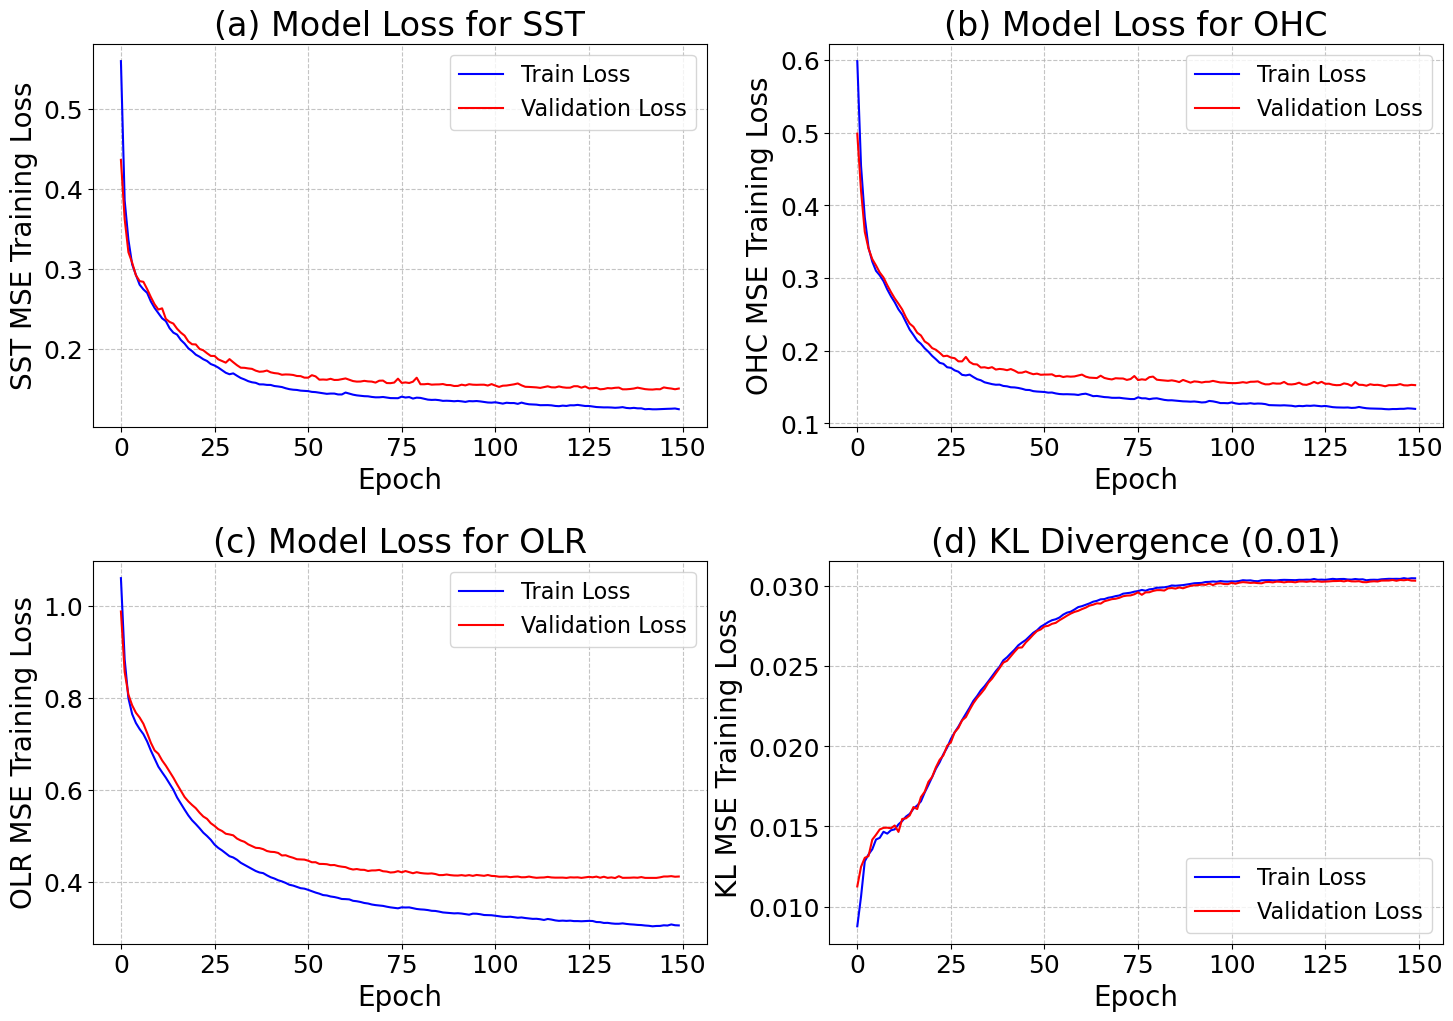

In [20]:
# create a 4x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.20, hspace=0.35)

# flatten the axes array for easier indexing
axes = axes.flatten()

for ax in axes:
    ax.tick_params(labelsize=18)               # larger tick labels
    ax.grid(True, linestyle='--', alpha=0.75)   # grid on

# Plot for SST Loss
axes[0].set_title('(a) Model Loss for SST', fontsize=24)
axes[0].set_xlabel('Epoch', fontsize=20)
axes[0].set_ylabel('SST MSE Training Loss', fontsize=20)
axes[0].plot(vae_model_history.history['sst_loss'], color='blue', label='Train Loss')
axes[0].plot(vae_model_history.history['val_sst_loss'], color='red', label='Validation Loss')
axes[0].legend(loc='best', fontsize=16)

# Plot for OHC Loss
axes[1].set_title('(b) Model Loss for OHC', fontsize=24)
axes[1].set_xlabel('Epoch', fontsize=20)
axes[1].set_ylabel('OHC MSE Training Loss', fontsize=20)
axes[1].plot(vae_model_history.history['ohc_loss'], color='blue', label='Train Loss')
axes[1].plot(vae_model_history.history['val_ohc_loss'], color='red', label='Validation Loss')
axes[1].legend(loc='best', fontsize=16)

# Plot for OLR Loss
axes[2].set_title('(c) Model Loss for OLR', fontsize=24)
axes[2].set_xlabel('Epoch', fontsize=20)
axes[2].set_ylabel('OLR MSE Training Loss', fontsize=20)
axes[2].plot(vae_model_history.history['olr_loss'], color='blue', label='Train Loss')
axes[2].plot(vae_model_history.history['val_olr_loss'], color='red', label='Validation Loss')
axes[2].legend(loc='best', fontsize=16)

# Plot for KL Loss
axes[3].set_title('(d) KL Divergence (0.01)', fontsize=24)
axes[3].set_xlabel('Epoch', fontsize=20)
axes[3].set_ylabel('KL MSE Training Loss', fontsize=20)
axes[3].plot(vae_model_history.history['kl_loss'], color='blue', label='Train Loss')
axes[3].plot(vae_model_history.history['val_kl_loss'], color='red', label='Validation Loss')
axes[3].legend(loc='best', fontsize=16)

#plt.savefig('trainingloss.pdf', bbox_inches='tight')
plt.show()